**ANÁLISIS DE COMPONENTES PRINCIPALES...?¿** 

vamos a analizar las componentes principales del dataset de Olvietti faces usando el algoritmo visto en clase con SVU

### 1. Importamos las librerias necesarias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from numpy.linalg import svd


### 2. Cargamos el dataset de las carotas

In [3]:
olivetti = fetch_olivetti_faces(shuffle=True)
print("Las imagenes bellas tienen dimensiones " + str(olivetti.images.shape))

Las imagenes bellas tienen dimensiones (400, 64, 64)


### 3. Visualicemos algunas imagenes del dataset 

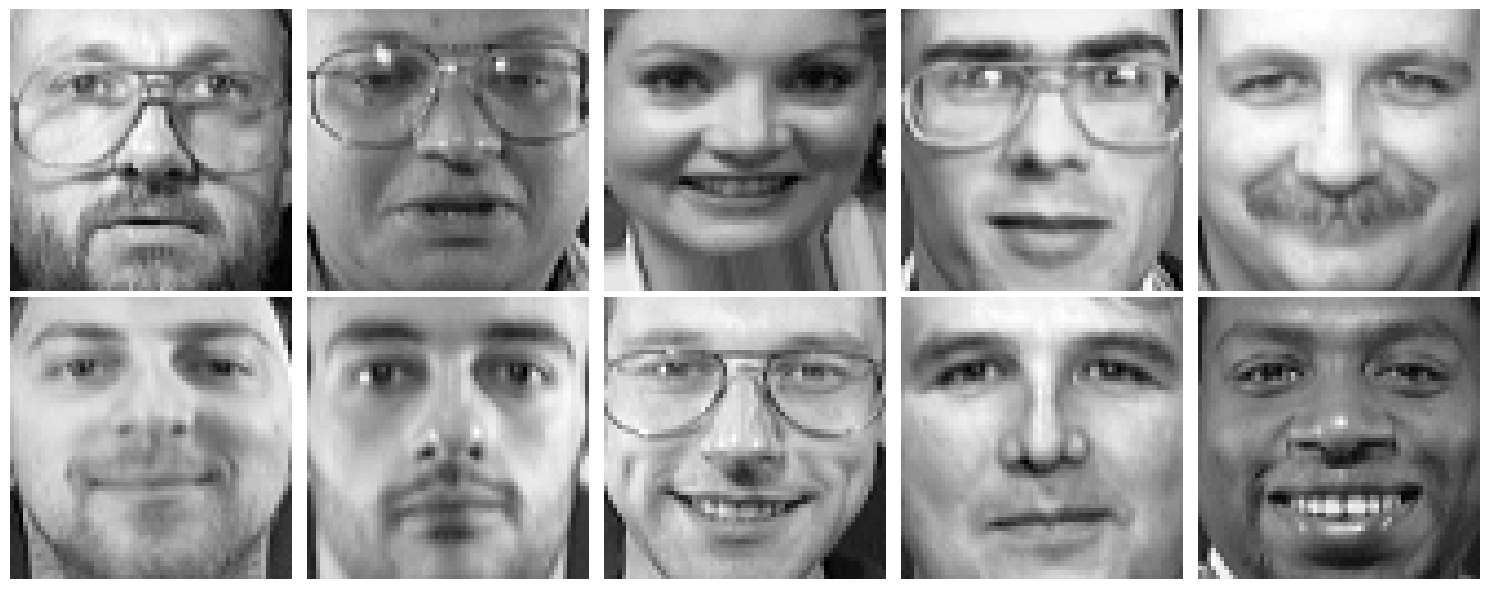

In [4]:

fig, axes = plt.subplots(2, 5, figsize=(15, 6)) # Crea un grid de 2x5 para mostrar 10 imágenes, de 15 x 6 pulgadas y donde fig y axes 
#son los objetos de la figura y los ejes respectivamente

for i, ax in enumerate(axes.flat): # Recorre los ejes en el grid creado anteriormente
    ax.imshow(olivetti.images[i], cmap='gray') # Muestra la imagen en escala de grises
    ax.axis('off')

plt.tight_layout() # Ajusta el diseño para evitar solapamientos


### 3. Calculamos su SVD y representamos sus 9 autovalores mas grandes

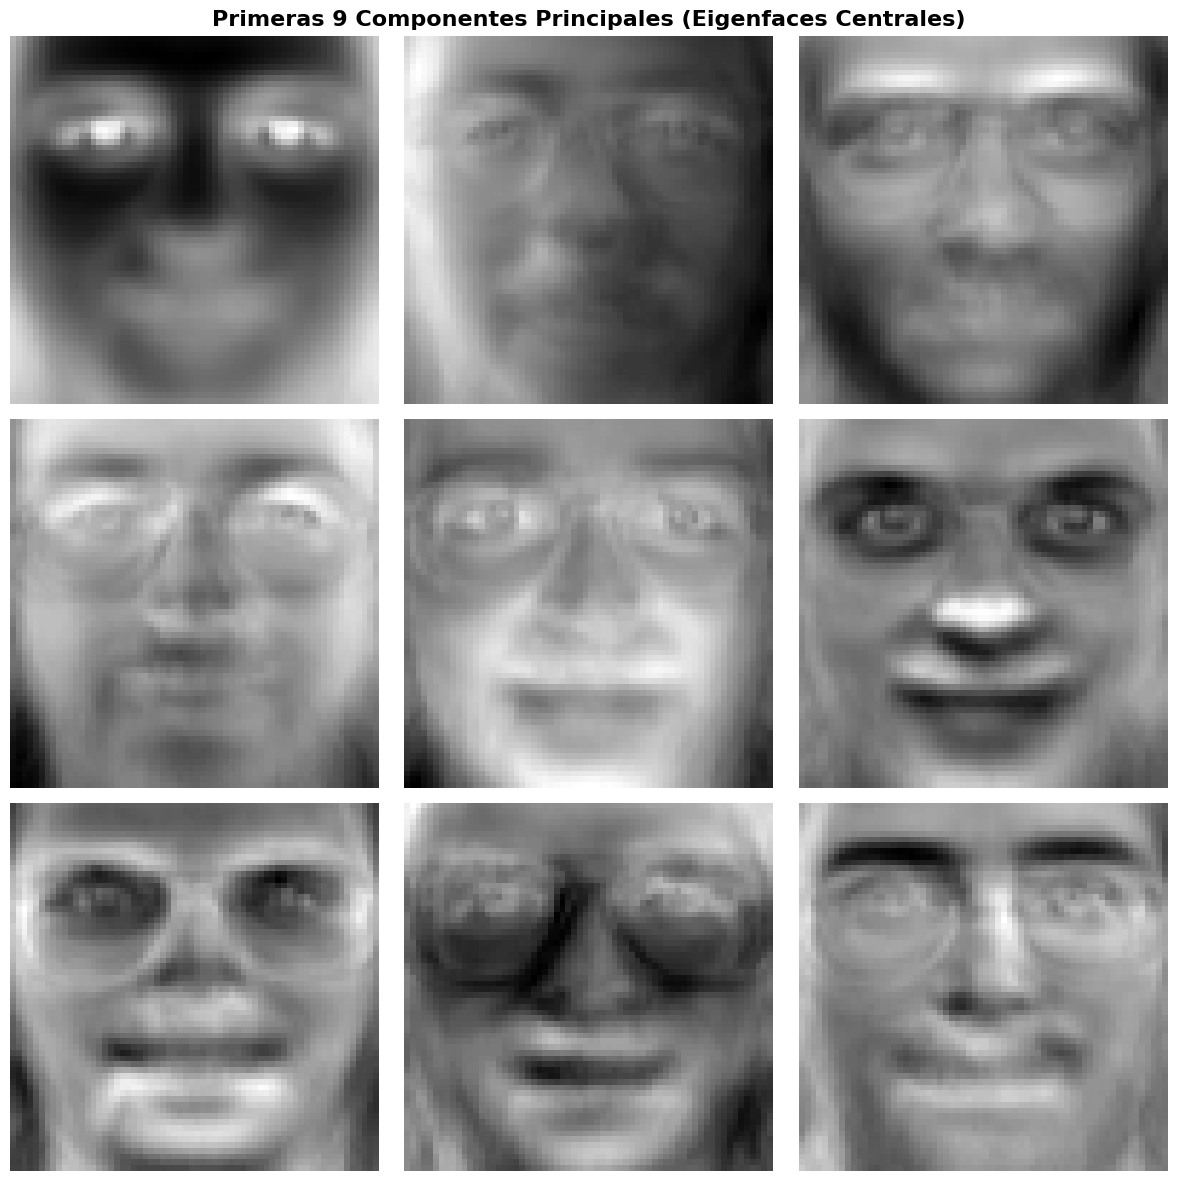

In [5]:
U, S, Vt = svd(olivetti.data, full_matrices=False) # Descomposición en valores singulares y full_matrices=False 
#para obtener matrices U y Vt de tamaño reducido

# Los autovalores son los valores singulares al cuadrado
eigenvalues = S ** 2

# Visualizar las primeras 9 componentes principales
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Primeras 9 Componentes Principales (Eigenfaces Centrales)', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat): # hacemos axes.flat para recorrer los ejes en el grid 3x3 
    eigenface = Vt[i].reshape(64, 64)  # Vt contiene las componentes principales como filas y las reestructuramos a 64x64
    ax.imshow(eigenface, cmap='gray') # Mostrar la eigenface en escala de grises
    ax.axis('off')
plt.tight_layout()

### 4. Veamos la gráfica logáritmica de sus autovalores

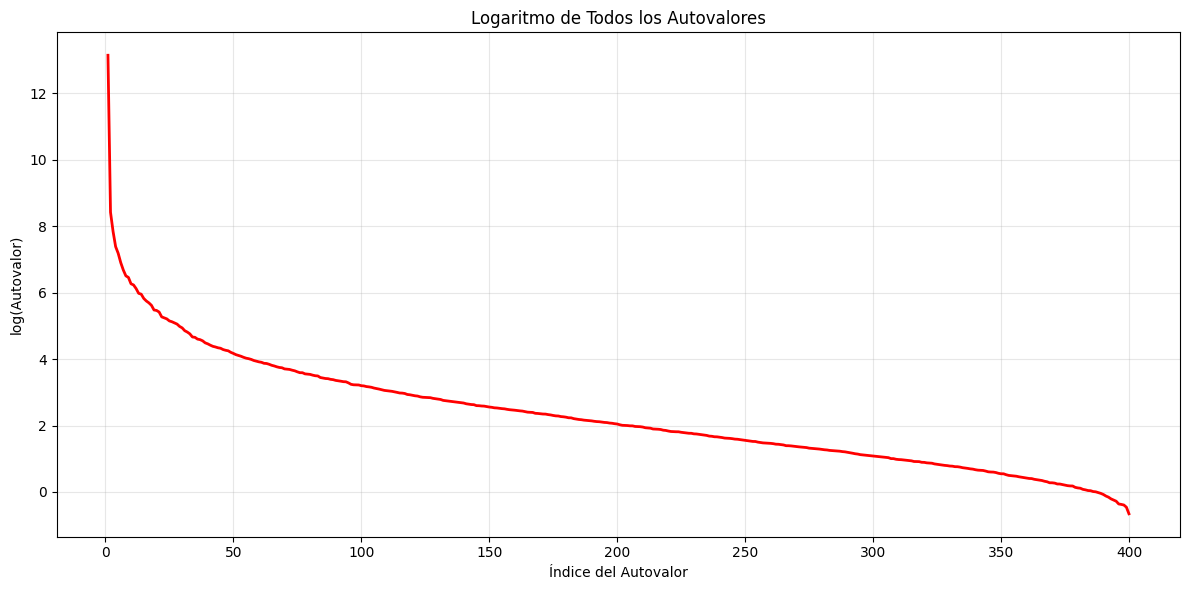

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(range(1, len(eigenvalues) + 1), np.log(eigenvalues), # nota: usamos np.log para el logaritmo natural 
         color='red', linewidth=2)
plt.xlabel('Índice del Autovalor')
plt.ylabel('log(Autovalor)')
plt.title('Logaritmo de Todos los Autovalores')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5. Ahora intentemos calcular los coeficientes en la base de la primera imagen

[-35.51806      4.2675347    2.2730906    1.2910242    0.94791186
   0.8342017   -0.6924422    1.235561    -1.9095362 ]


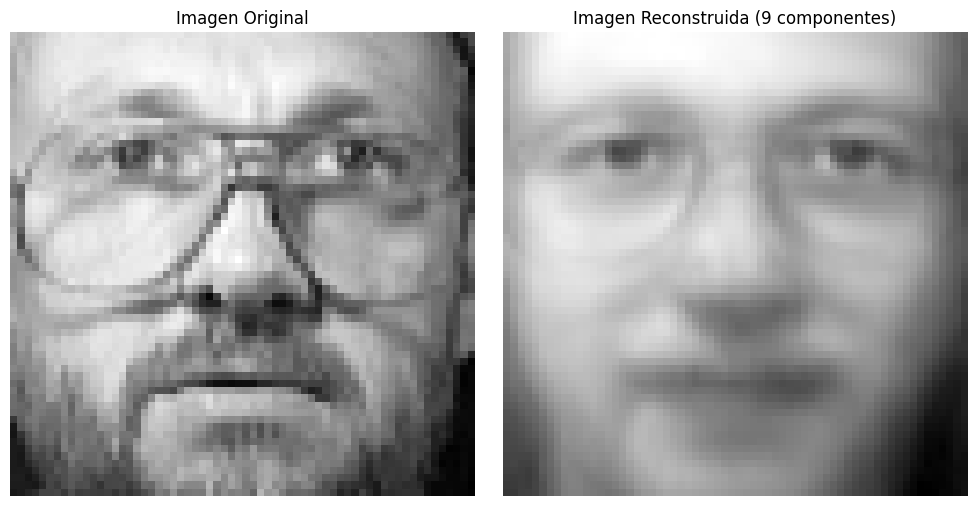


Error de reconstrucción (norma L2): 5.7489


In [8]:
primera_imagen = olivetti.data[0]

# Calcular los coeficientes (proyección sobre las 9 primeras componentes)
n_componentes = 9
coeficientes = np.dot(primera_imagen, Vt[:n_componentes].T)

print(coeficientes)

# Reconstruir la imagen usando solo las 9 primeras componentes
imagen_reconstruida = np.dot(coeficientes, Vt[:n_componentes])

# Visualizar: Original vs Reconstruida
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Imagen original
axes[0].imshow(primera_imagen.reshape(64, 64), cmap='gray')
axes[0].set_title('Imagen Original')
axes[0].axis('off')

# Imagen reconstruida
axes[1].imshow(imagen_reconstruida.reshape(64, 64), cmap='gray')
axes[1].set_title('Imagen Reconstruida (9 componentes)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Calcular el error de reconstrucción
error = np.linalg.norm(primera_imagen - imagen_reconstruida)
print(f"\nError de reconstrucción (norma L2): {error:.4f}")